# Optimización. Laboratorio #6.

ESTUDIANTE: VALDA PLAZA CAMILA MONSERRAT.
LABORATORIO: #6.
CARRERA: INGENIERIA DE SISTEMAS.

ESTE DATASET NOS HABLA DE 15 TIPOS DE VEGETABLES, SON IMAGENES REALES TOMADAS EN UNA GRANJA Y RECOLETADAS.

LO QUE SE HIZO PRIMERAMENTE FUE EN COLAB LA PRACTICA DONDE SE ESTA DESCARGANDO DESDE KAGGLE SIN NECESIDAD DE LLAMAR A UNA RUTA, DADO QUE EL ARCHIVO ERA DEMASIADO PESADO.

SE HIZO VARIAS PRUEBAS PARA MEJORAR LA PRECISION DONDE EN EL COMIENZO SE UTILIZÓ DATA AUMENTATION, CON COMPOSE PERO LA PRECISION LLEGABA A UN 65% TANTO EN EL ENTREAMIENTO COMO EN EL PRECSION, DANDO CERCANIA EN SU RESULTADO, ESO INDICABA BUENA GENERALIZACION, PERO SE DECIDIÓ COMENTAR DADO QUE SIN ELLO SE HA LLEGADO CON ADAM A UN 80% MUY CERCANO AL ENTRENAMIENTO Y PRECISION RESULTANDO ASI UNA MEJOR GENERALIZACION.

In [1]:
import kagglehub

path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 534M/534M [00:05<00:00, 105MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/misrakahmed/vegetable-image-dataset/versions/1


In [2]:
import os

dataset_dir = path
print("Contenido de dataset_dir:", os.listdir(dataset_dir))
for root, dirs, files in os.walk(dataset_dir):
    print(root, dirs)
    break

Contenido de dataset_dir: ['Vegetable Images']
/root/.cache/kagglehub/datasets/misrakahmed/vegetable-image-dataset/versions/1 ['Vegetable Images']


In [3]:
import os

dataset_dir = os.path.join(path, 'Vegetable Images')

train_dir = os.path.join(dataset_dir, 'train')
test_dir  = os.path.join(dataset_dir, 'test')

num_train = sum([len(files) for r, d, files in os.walk(train_dir)])
num_test  = sum([len(files) for r, d, files in os.walk(test_dir)])

print("Número de imágenes en train:", num_train)
print("Número de imágenes en test:", num_test)

classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
num_classes = len(classes)

print("Clases:", classes)
print("Número de clases:", num_classes)

Número de imágenes en train: 15000
Número de imágenes en test: 3000
Clases: ['Broccoli', 'Pumpkin', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Cauliflower', 'Capsicum', 'Cucumber', 'Radish', 'Cabbage', 'Papaya', 'Carrot', 'Potato', 'Bean', 'Tomato']
Número de clases: 15


In [4]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets

transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    #transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(15),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    #transforms.ToTensor(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

trainset = datasets.ImageFolder(root=train_dir, transform=transform_train)
testset  = datasets.ImageFolder(root=test_dir, transform=transform_test)

print("Trainset:", len(trainset), "Testset:", len(testset))
print("Clases:", trainset.classes)
print("Número de clases:", len(trainset.classes))

Trainset: 15000 Testset: 3000
Clases: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Número de clases: 15


In [5]:
import numpy as np

train_images = np.array([np.array(img) for img, label in trainset])
X_test = np.array([np.array(img) for img, label in testset])

train_labels = np.array([label for img, label in trainset])
y_test = np.array([label for img, label in testset])
perm = np.random.permutation(len(train_images))
train_images = train_images[perm]
train_labels = train_labels[perm]

X_train, X_val, X_subset = train_images[:13500], train_images[13500:], train_images[:10000]
y_train, y_val, y_subset = train_labels[:13500], train_labels[13500:], train_labels[:10000]

X_train.shape, X_val.shape, X_test.shape, X_subset.shape

((13500, 3, 64, 64), (1500, 3, 64, 64), (3000, 3, 64, 64), (10000, 3, 64, 64))

In [6]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        X_flat = X.reshape(len(X), -1)
        self.X = torch.from_numpy((X_flat / 255.).astype(np.float32)).float().cuda()
        self.Y = torch.from_numpy(Y).long().cuda()
    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset = {
    'train': Dataset(X_subset, y_subset),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(10000, 1500)

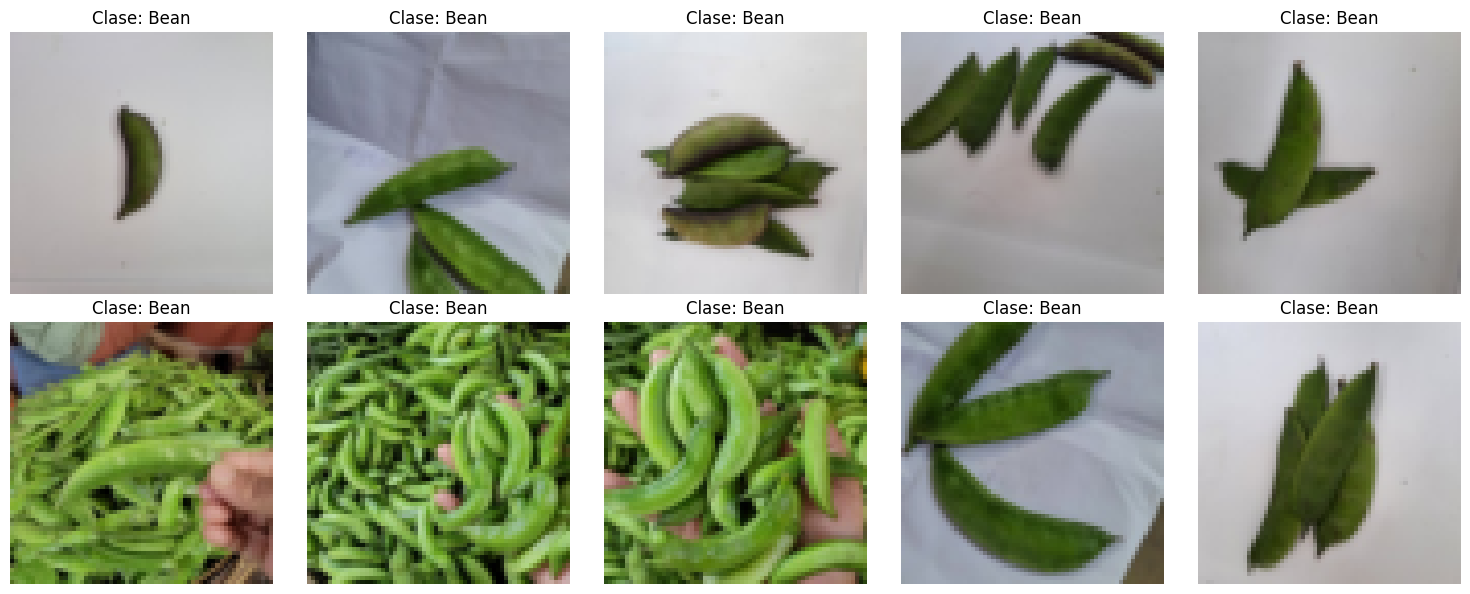

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(image_tensor):
    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]
    image = image_tensor.clone()

    for i in range(3):
        image[i] = (image[i] * std[i]) + mean[i]
    image = image.numpy().transpose((1, 2, 0))
    image = np.clip(image, 0, 1)

    return image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    image, label = trainset[i]
    denormalized_image = denormalize(image)
    axes[i].imshow(denormalized_image)
    axes[i].set_title(f'Clase: {trainset.classes[label]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

#def build_model(D_in=80*80*3, H=150, D_out=15):
    #return torch.nn.Sequential(
        #torch.nn.Linear(D_in, H),
        #torch.nn.ReLU(),
        #torch.nn.Linear(H, H),
        #torch.nn.ReLU(),
        #torch.nn.Linear(H, D_out)
   # ).cuda()
def build_model(D_in=64*64*3, H=150, D_out=15):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p=0.5),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p=0.5),
        torch.nn.Linear(H, D_out)
    ).cuda()

def fit(model, dataloader, optimizer, epochs=500, log_each=10, weight_decay=0, early_stopping=80):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                # versión original
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

## Optimizadores

### Comparativa

Vamos a comparar los diferentes optimizadores presentados.

In [9]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.07350 en epoch 1
Epoch 10/500 loss 2.70868 acc 0.06909 val_loss 2.70745 val_acc 0.07350
Epoch 20/500 loss 2.70882 acc 0.06779 val_loss 2.70772 val_acc 0.07350
Epoch 30/500 loss 2.70832 acc 0.07019 val_loss 2.70799 val_acc 0.07350
Epoch 40/500 loss 2.70822 acc 0.06540 val_loss 2.70822 val_acc 0.07350
Epoch 50/500 loss 2.70799 acc 0.06589 val_loss 2.70840 val_acc 0.07350
Mejor modelo guardado con acc 0.07700 en epoch 56
Mejor modelo guardado con acc 0.10550 en epoch 57
Epoch 60/500 loss 2.70773 acc 0.06839 val_loss 2.70854 val_acc 0.06150
Epoch 70/500 loss 2.70813 acc 0.06929 val_loss 2.70865 val_acc 0.06150
Epoch 80/500 loss 2.70792 acc 0.06949 val_loss 2.70872 val_acc 0.06150
Epoch 90/500 loss 2.70770 acc 0.06839 val_loss 2.70877 val_acc 0.06150
Epoch 100/500 loss 2.70779 acc 0.06779 val_loss 2.70881 val_acc 0.06150
Epoch 110/500 loss 2.70786 acc 0.07009 val_loss 2.70884 val_acc 0.06150
Epoch 120/500 loss 2.70753 acc 0.06999 val_loss 2.70884 val_acc 0.06

In [10]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.06950 en epoch 1
Mejor modelo guardado con acc 0.11600 en epoch 6
Epoch 10/500 loss 2.69164 acc 0.09585 val_loss 2.67886 val_acc 0.11300
Mejor modelo guardado con acc 0.13100 en epoch 11
Mejor modelo guardado con acc 0.13250 en epoch 12
Mejor modelo guardado con acc 0.19950 en epoch 13
Mejor modelo guardado con acc 0.21400 en epoch 18
Mejor modelo guardado con acc 0.24250 en epoch 19
Mejor modelo guardado con acc 0.27050 en epoch 20
Epoch 20/500 loss 2.21884 acc 0.22744 val_loss 2.12249 val_acc 0.27050
Mejor modelo guardado con acc 0.28050 en epoch 21
Mejor modelo guardado con acc 0.31800 en epoch 22
Mejor modelo guardado con acc 0.32150 en epoch 23
Mejor modelo guardado con acc 0.33550 en epoch 24
Mejor modelo guardado con acc 0.38300 en epoch 27
Mejor modelo guardado con acc 0.38350 en epoch 30
Epoch 30/500 loss 1.91658 acc 0.31779 val_loss 1.79093 val_acc 0.38350
Mejor modelo guardado con acc 0.38550 en epoch 33
Mejor modelo guardado con acc 0.40350 e

In [11]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.43150 en epoch 1
Mejor modelo guardado con acc 0.52300 en epoch 2
Mejor modelo guardado con acc 0.55300 en epoch 3
Mejor modelo guardado con acc 0.58200 en epoch 4
Mejor modelo guardado con acc 0.60250 en epoch 5
Mejor modelo guardado con acc 0.63600 en epoch 6
Mejor modelo guardado con acc 0.64900 en epoch 7
Mejor modelo guardado con acc 0.68450 en epoch 8
Mejor modelo guardado con acc 0.68700 en epoch 9
Mejor modelo guardado con acc 0.69800 en epoch 10
Epoch 10/500 loss 1.05116 acc 0.66354 val_loss 0.92719 val_acc 0.69800
Mejor modelo guardado con acc 0.72100 en epoch 11
Mejor modelo guardado con acc 0.72250 en epoch 12
Mejor modelo guardado con acc 0.72300 en epoch 13
Mejor modelo guardado con acc 0.74750 en epoch 14
Mejor modelo guardado con acc 0.75100 en epoch 15
Mejor modelo guardado con acc 0.76550 en epoch 16
Mejor modelo guardado con acc 0.77050 en epoch 17
Mejor modelo guardado con acc 0.77100 en epoch 18
Mejor modelo guardado con acc 0.77450 

In [12]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.40000 en epoch 1
Mejor modelo guardado con acc 0.49650 en epoch 2
Mejor modelo guardado con acc 0.51950 en epoch 3
Mejor modelo guardado con acc 0.54650 en epoch 4
Mejor modelo guardado con acc 0.57000 en epoch 5
Mejor modelo guardado con acc 0.59600 en epoch 6
Mejor modelo guardado con acc 0.60450 en epoch 7
Mejor modelo guardado con acc 0.62650 en epoch 8
Mejor modelo guardado con acc 0.65550 en epoch 9
Mejor modelo guardado con acc 0.66200 en epoch 10
Epoch 10/500 loss 1.14685 acc 0.62810 val_loss 1.07509 val_acc 0.66200
Mejor modelo guardado con acc 0.70250 en epoch 12
Mejor modelo guardado con acc 0.70750 en epoch 13
Mejor modelo guardado con acc 0.72000 en epoch 14
Mejor modelo guardado con acc 0.73050 en epoch 15
Mejor modelo guardado con acc 0.73800 en epoch 16
Mejor modelo guardado con acc 0.74100 en epoch 17
Mejor modelo guardado con acc 0.75150 en epoch 18
Mejor modelo guardado con acc 0.75350 en epoch 19
Mejor modelo guardado con acc 0.75850 

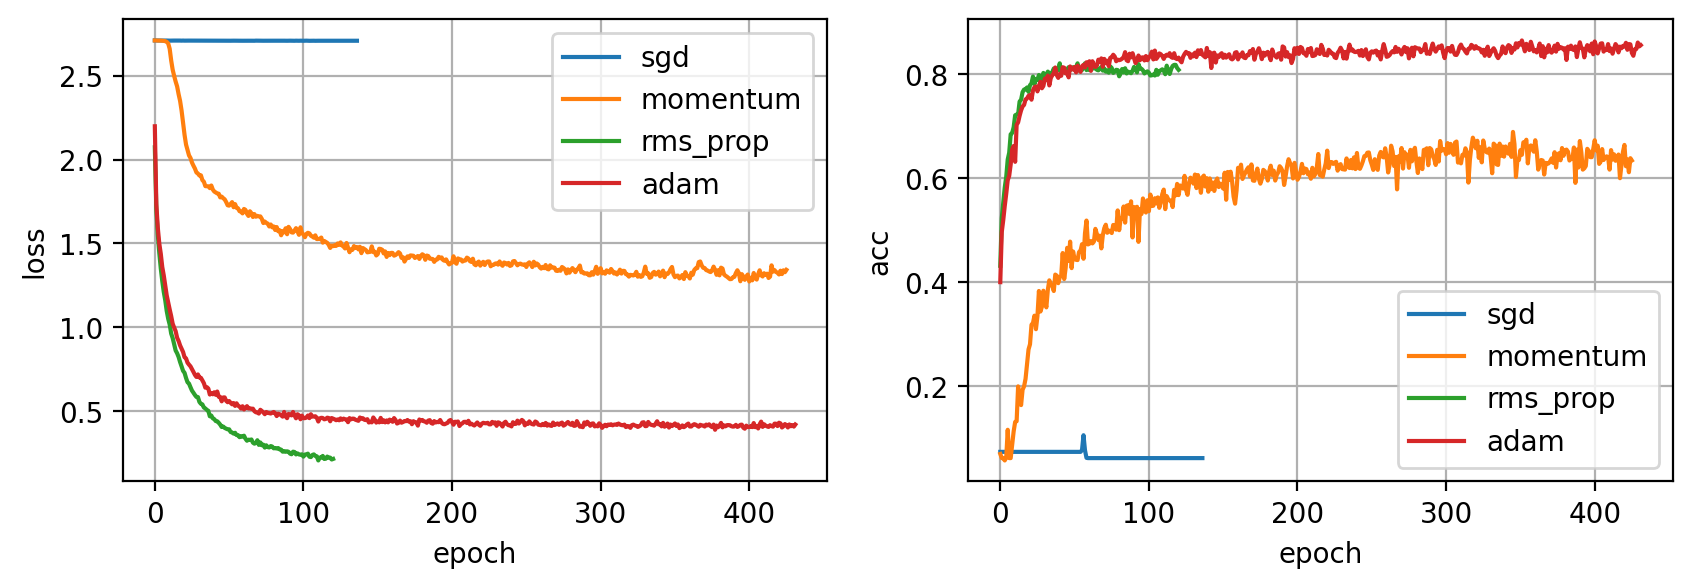

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="sgd")
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_rms['loss'], label="rms_prop")
ax.plot(hist_adam['loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="sgd")
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_rms['val_acc'], label="rms_prop")
ax.plot(hist_adam['val_acc'], label="adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

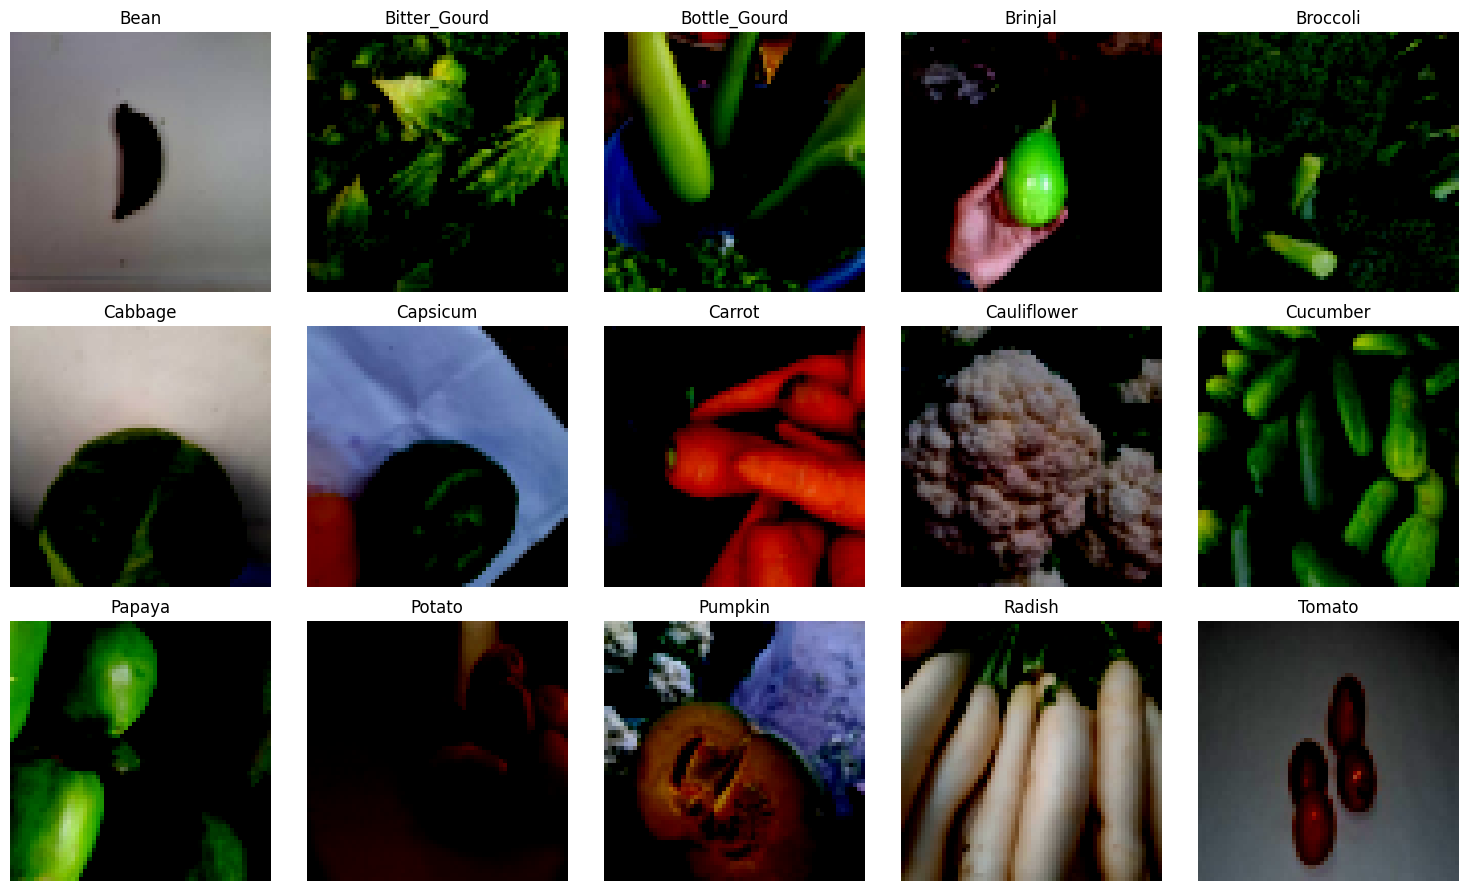

In [14]:
import matplotlib.pyplot as plt
import numpy as np

num_classes = len(trainset.classes)
r, c = 3, 5
plt.figure(figsize=(c*3, r*3))

for i in range(num_classes):
    for idx in range(len(trainset)):
        img, label = trainset[idx]
        if label == i:
            break
    img_np = np.transpose(img.numpy(), (1, 2, 0))
    plt.subplot(r, c, i+1)
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(trainset.classes[i])

plt.tight_layout()
plt.show()

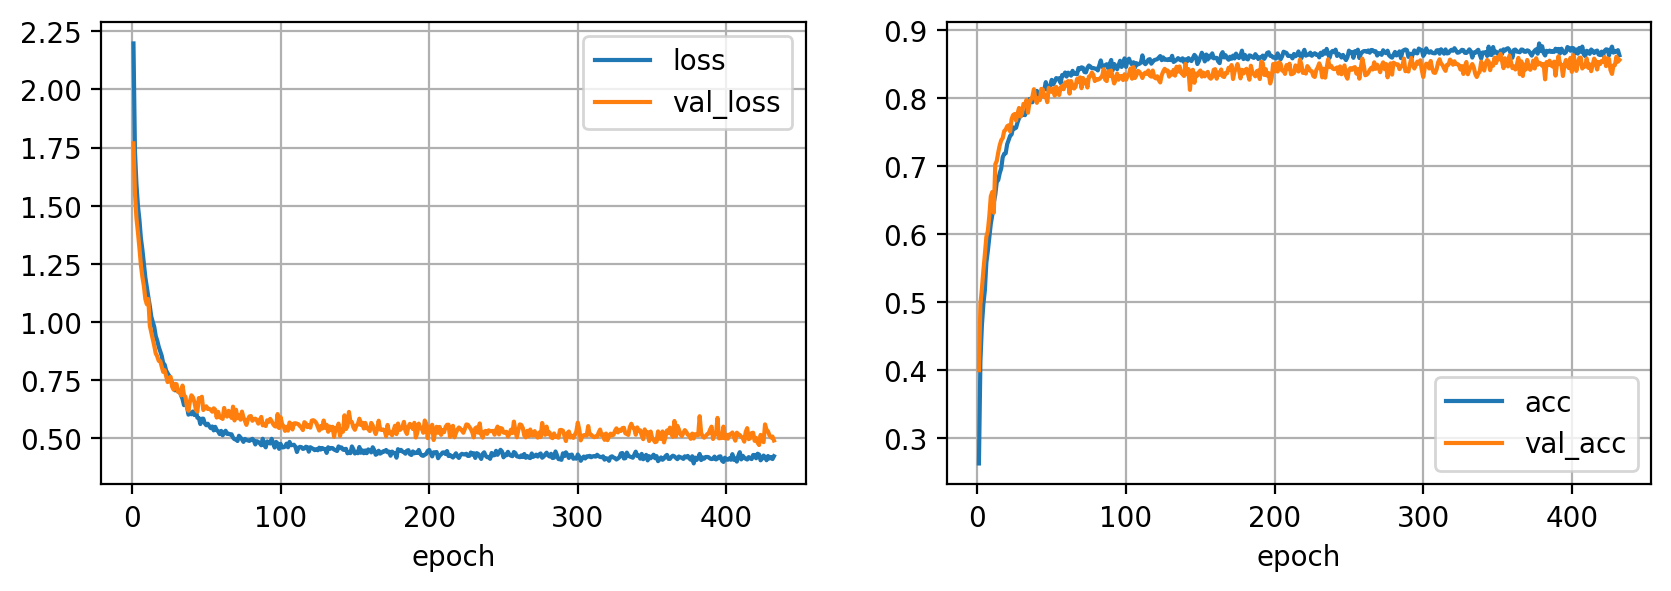

In [15]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_adam).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_adam).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

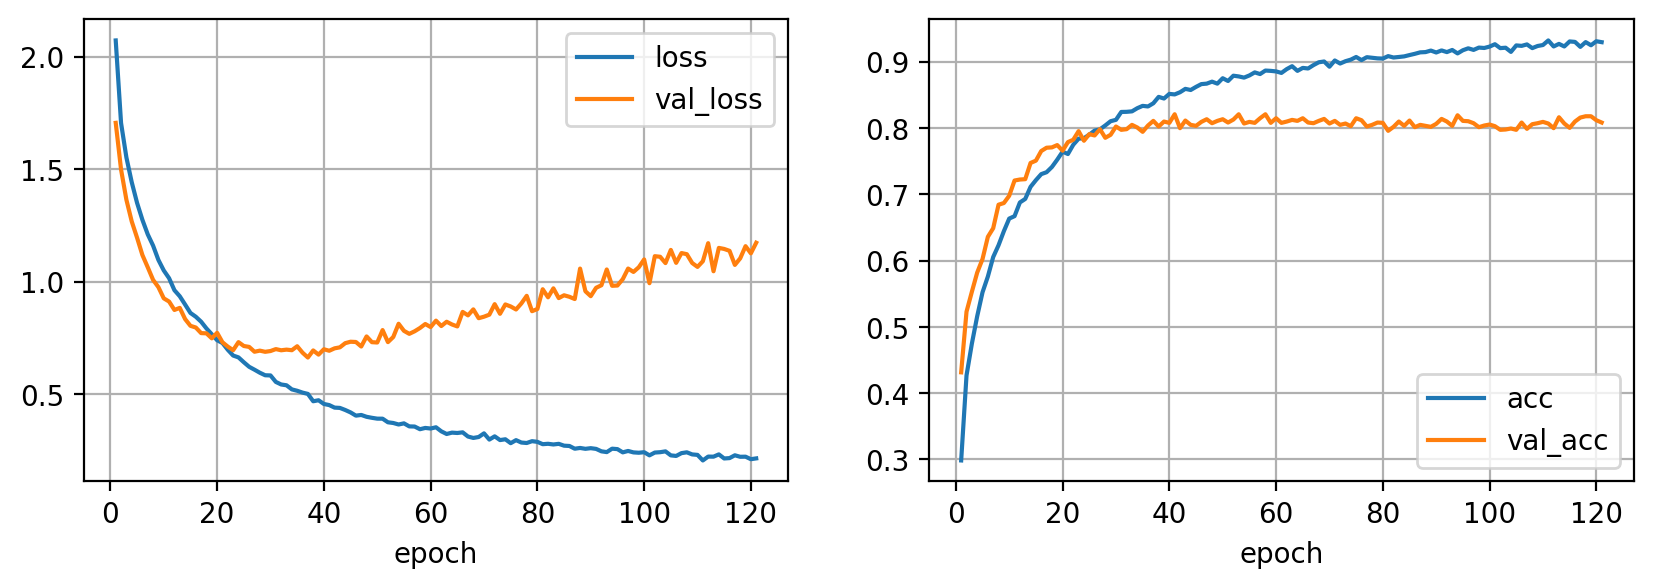

In [16]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_rms).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_rms).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

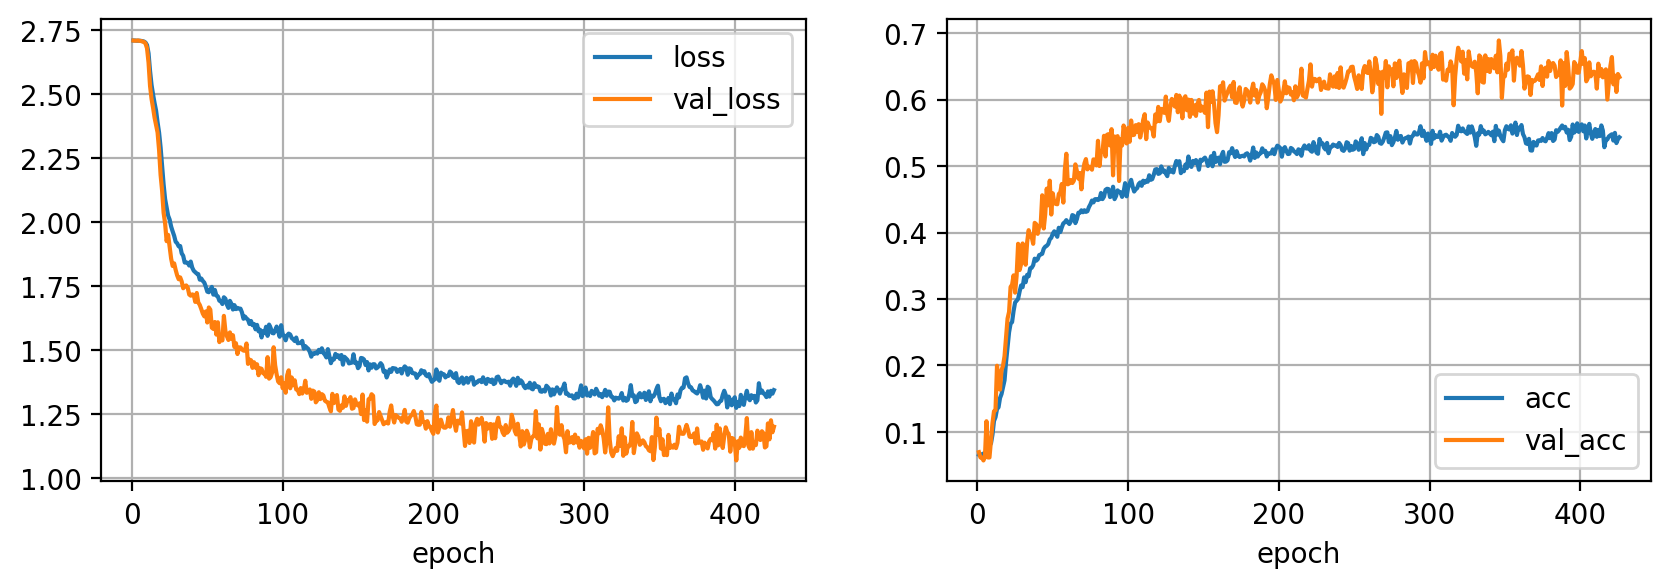

In [17]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_momentum).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_momentum).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

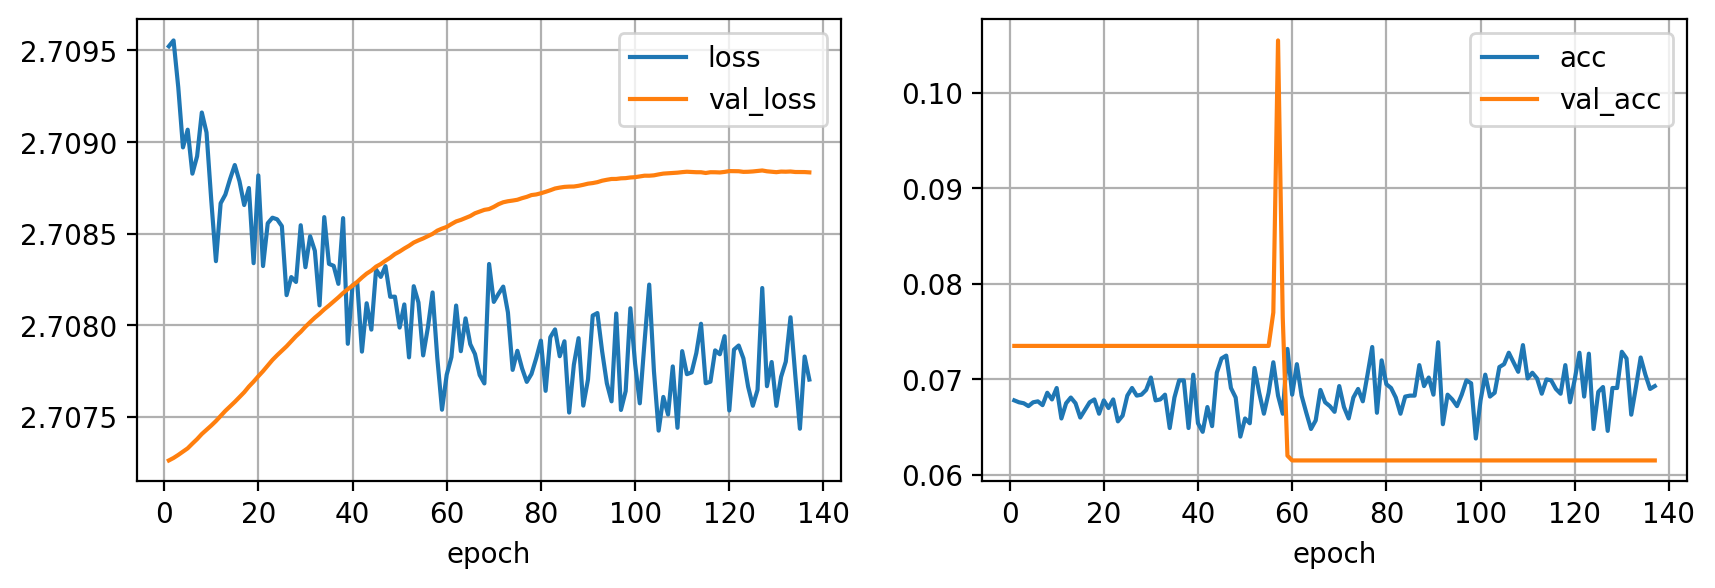

In [18]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_sgd).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_sgd).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

## *Learning Rate Scheduling*

In [19]:
def fit(model, dataloader, optimizer, scheduler=None, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        if scheduler:
            scheduler.step()
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

In [20]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10, 0.1)

hist_step = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.07800 en epoch 1
Mejor modelo guardado con acc 0.10050 en epoch 6
Mejor modelo guardado con acc 0.10200 en epoch 7
Mejor modelo guardado con acc 0.11850 en epoch 10
Epoch 10/30 loss 2.68649 acc 0.10783 val_loss 2.67228 val_acc 0.11850 lr 0.01000
Mejor modelo guardado con acc 0.15350 en epoch 11
Mejor modelo guardado con acc 0.15650 en epoch 12
Epoch 20/30 loss 2.61735 acc 0.12161 val_loss 2.60315 val_acc 0.13900 lr 0.00100
Epoch 30/30 loss 2.60334 acc 0.12300 val_loss 2.59446 val_acc 0.13900 lr 0.00010


In [21]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0001, max_lr=0.01, step_size_up=5, step_size_down=25)

hist_cycle = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.06800 en epoch 1
Mejor modelo guardado con acc 0.07350 en epoch 2
Mejor modelo guardado con acc 0.07450 en epoch 7
Mejor modelo guardado con acc 0.07700 en epoch 9
Epoch 10/30 loss 2.70747 acc 0.06989 val_loss 2.70767 val_acc 0.06150 lr 0.00842
Mejor modelo guardado con acc 0.08350 en epoch 13
Mejor modelo guardado con acc 0.08750 en epoch 15
Mejor modelo guardado con acc 0.12400 en epoch 17
Mejor modelo guardado con acc 0.12500 en epoch 18
Mejor modelo guardado con acc 0.15050 en epoch 20
Epoch 20/30 loss 2.69290 acc 0.10723 val_loss 2.68968 val_acc 0.15050 lr 0.00446
Epoch 30/30 loss 2.59720 acc 0.12500 val_loss 2.58791 val_acc 0.13250 lr 0.00050


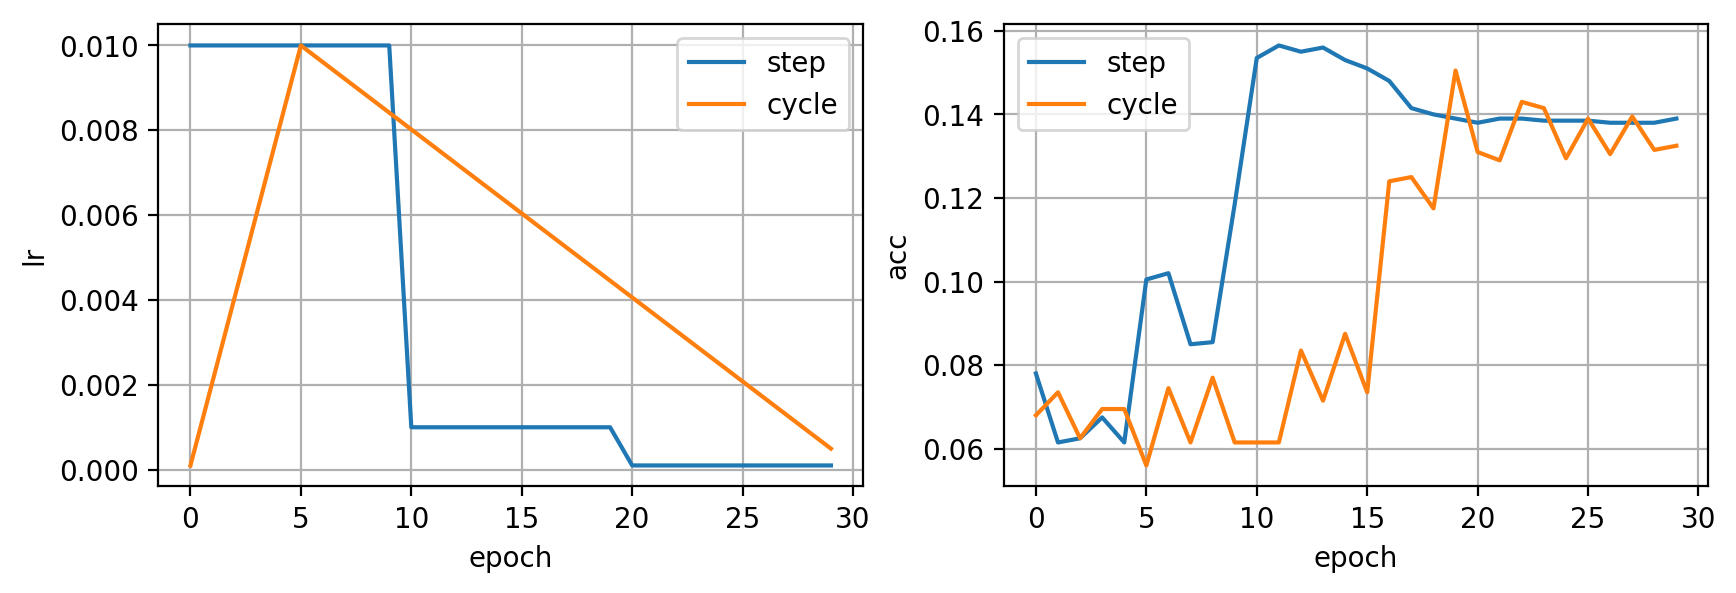

In [22]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_step['lr'], label="step")
ax.plot(hist_cycle['lr'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('lr')
ax = plt.subplot(122)
ax.plot(hist_step['val_acc'], label="step")
ax.plot(hist_cycle['val_acc'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

## Normalización

In [23]:
import numpy as np

mean = (train_images / 255).mean(axis=(0, 1, 2))
std = (train_images / 255).std(axis=(0, 1, 2))

mean, std

(array([-0.000604  , -0.00059259, -0.00058423, -0.00057614, -0.00057167,
        -0.00056876, -0.00056201, -0.00055379, -0.00054691, -0.00054097,
        -0.00053485, -0.00053406, -0.00053653, -0.00053734, -0.00053812,
        -0.00053897, -0.00054226, -0.00054649, -0.00055388, -0.00056237,
        -0.00056947, -0.00057483, -0.00057699, -0.00057831, -0.00057824,
        -0.00057882, -0.00057654, -0.00057494, -0.0005726 , -0.00057232,
        -0.00057384, -0.00057568, -0.00057668, -0.00057697, -0.00057772,
        -0.00058104, -0.00058499, -0.00058793, -0.00059092, -0.00059485,
        -0.00060078, -0.0006067 , -0.00060894, -0.00061002, -0.00060694,
        -0.00060296, -0.00060112, -0.00060063, -0.00060184, -0.00060262,
        -0.00060396, -0.00060689, -0.00061045, -0.00061252, -0.0006154 ,
        -0.00062377, -0.00063077, -0.00063596, -0.00063962, -0.00063996,
        -0.00064124, -0.00064619, -0.00065293, -0.00065889], dtype=float32),
 array([0.00190576, 0.00189287, 0.00188799, 0.0

In [24]:
train_images_norm = ((train_images / 255) - mean) / std
train_images_norm.mean(axis=(0, 1, 2)), train_images_norm.std(axis=(0, 1, 2))

(array([0.00029868, 0.00027513, 0.00028477, 0.00029561, 0.00028336,
        0.00029012, 0.00029035, 0.00028001, 0.00028851, 0.00026323,
        0.00024874, 0.00023391, 0.00024324, 0.00025485, 0.00024717,
        0.00023652, 0.00024953, 0.00024283, 0.00023631, 0.00025548,
        0.00024984, 0.00024908, 0.00025858, 0.000259  , 0.00024369,
        0.0002332 , 0.00024127, 0.00025327, 0.00024812, 0.00023177,
        0.00024232, 0.00023875, 0.00023853, 0.00023032, 0.00023125,
        0.00021273, 0.00022707, 0.00022749, 0.00023766, 0.00022388,
        0.00023404, 0.00022857, 0.000245  , 0.00025542, 0.00025107,
        0.00025458, 0.00024681, 0.00025529, 0.00026483, 0.00026879,
        0.00028088, 0.00024659, 0.00025754, 0.00028619, 0.00028654,
        0.00028154, 0.00029786, 0.00029984, 0.00030519, 0.00029674,
        0.00029788, 0.00031198, 0.0003081 , 0.00035828], dtype=float32),
 array([1.000734  , 0.9999814 , 0.9994039 , 1.000103  , 1.0001609 ,
        0.99938923, 0.99998224, 0.9989584 ,

In [25]:
X_test_norm = np.array([(np.array(img)/255. - mean) / std for img, label in testset])

X_train_norm, X_val_norm, X_subset_norm = train_images_norm[:13500], train_images_norm[13500:], train_images_norm[:5000]

X_train_norm.shape, X_val_norm.shape, X_test_norm.shape, X_subset_norm.shape

((13500, 3, 64, 64), (1500, 3, 64, 64), (3000, 3, 64, 64), (5000, 3, 64, 64))

In [26]:
# Añade esto antes para debug
print("Shape de X_subset_norm:", X_subset_norm.shape if hasattr(X_subset_norm, 'shape') else "NO EXISTE")
print("Shape de X_val_norm:", X_val_norm.shape if hasattr(X_val_norm, 'shape') else "NO EXISTE")
print("Shape de y_subset:", y_subset.shape)
print("Shape de y_val:", y_val.shape)

Shape de X_subset_norm: (5000, 3, 64, 64)
Shape de X_val_norm: (1500, 3, 64, 64)
Shape de y_subset: (10000,)
Shape de y_val: (1500,)


In [27]:
X_val_norm = train_images_norm[13500:13500 + len(y_val)]
dataset_norm = {
    'train': Dataset(X_subset_norm, y_subset),
    'val': Dataset(X_val_norm, y_val),
}

dataloader_norm = {
    'train': torch.utils.data.DataLoader(dataset_norm['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset_norm['val'], batch_size=1000, shuffle=False)
}

len(dataset_norm['train']), len(dataset_norm['val'])

(5000, 1500)

In [28]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_norm = fit(model, dataloader_norm, optimizer)

Mejor modelo guardado con acc 0.07450 en epoch 1
Mejor modelo guardado con acc 0.07550 en epoch 3
Mejor modelo guardado con acc 0.07800 en epoch 4
Epoch 10/100 loss 2.70694 acc 0.07305 val_loss 2.70707 val_acc 0.06950 lr 0.00100
Mejor modelo guardado con acc 0.08300 en epoch 11
Mejor modelo guardado con acc 0.10400 en epoch 14
Mejor modelo guardado con acc 0.10450 en epoch 15
Epoch 20/100 loss 2.70540 acc 0.07385 val_loss 2.70630 val_acc 0.10350 lr 0.00100
Mejor modelo guardado con acc 0.10750 en epoch 23
Mejor modelo guardado con acc 0.11150 en epoch 29
Epoch 30/100 loss 2.70426 acc 0.08300 val_loss 2.70497 val_acc 0.10400 lr 0.00100
Mejor modelo guardado con acc 0.11200 en epoch 40
Epoch 40/100 loss 2.70127 acc 0.09136 val_loss 2.70229 val_acc 0.11200 lr 0.00100
Epoch 50/100 loss 2.69611 acc 0.09713 val_loss 2.69658 val_acc 0.10400 lr 0.00100
Epoch 60/100 loss 2.68401 acc 0.10967 val_loss 2.68283 val_acc 0.10350 lr 0.00100
Mejor modelo guardado con acc 0.11350 en epoch 62
Mejor model

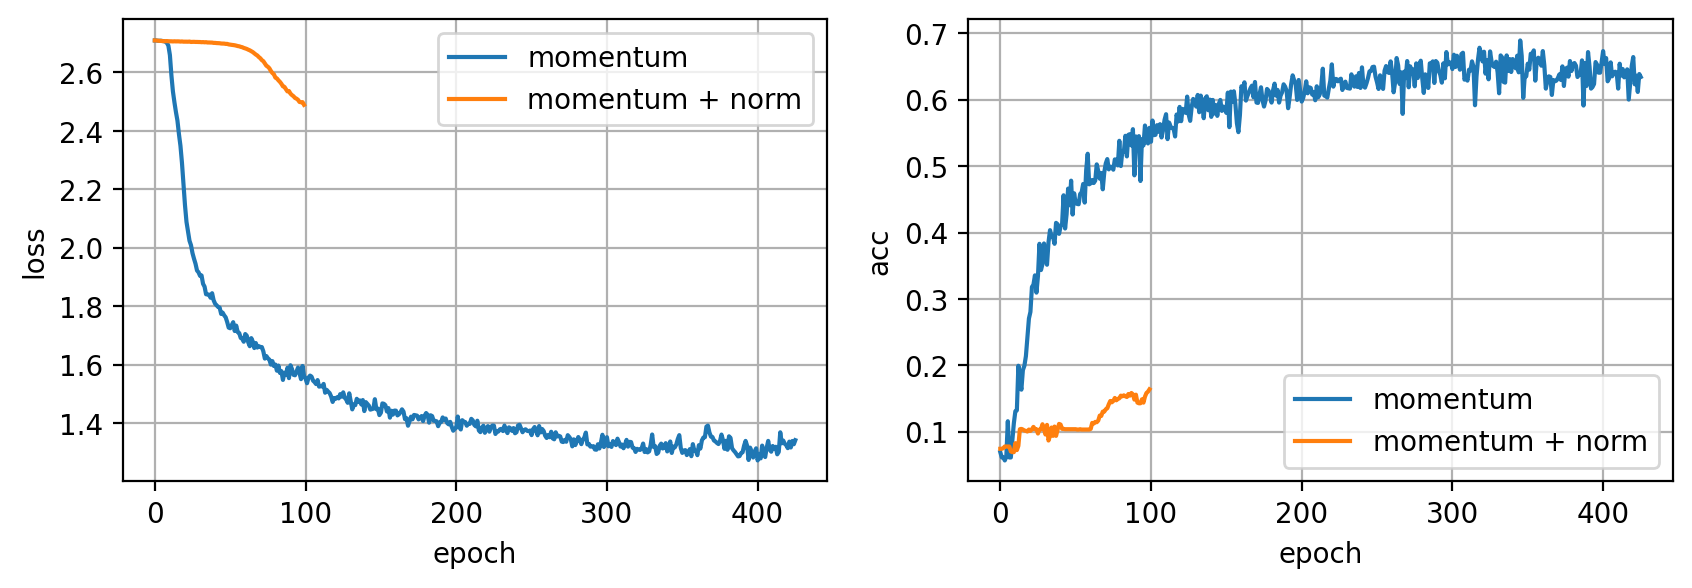

In [29]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_norm['loss'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_norm['val_acc'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

En este caso, el efecto de la normalización no es considerable (al trabajar con imágenes éste suele ser el caso).

### *Batch Normalization*

In [30]:
def build_model():
    return torch.nn.Sequential(
        torch.nn.Flatten(),
        torch.nn.Linear(64*64*3, 100),
        torch.nn.BatchNorm1d(100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 100),
        torch.nn.BatchNorm1d(100),
        torch.nn.ReLU(),
        torch.nn.Linear(100, 15)
    ).cuda()

In [31]:
model = build_model().cuda()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_bn = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.62050 en epoch 1
Mejor modelo guardado con acc 0.69850 en epoch 2
Mejor modelo guardado con acc 0.74600 en epoch 3
Mejor modelo guardado con acc 0.76250 en epoch 4
Mejor modelo guardado con acc 0.78200 en epoch 5
Mejor modelo guardado con acc 0.79250 en epoch 6
Mejor modelo guardado con acc 0.80250 en epoch 8
Epoch 10/100 loss 0.19890 acc 0.96346 val_loss 0.67910 val_acc 0.79950 lr 0.00100
Mejor modelo guardado con acc 0.80450 en epoch 12
Mejor modelo guardado con acc 0.80900 en epoch 13
Mejor modelo guardado con acc 0.81300 en epoch 14
Mejor modelo guardado con acc 0.81450 en epoch 15
Mejor modelo guardado con acc 0.81550 en epoch 16
Mejor modelo guardado con acc 0.81900 en epoch 18
Mejor modelo guardado con acc 0.82350 en epoch 20
Epoch 20/100 loss 0.05933 acc 0.99042 val_loss 0.66796 val_acc 0.82350 lr 0.00100
Epoch 30/100 loss 0.03014 acc 0.99661 val_loss 0.68230 val_acc 0.81400 lr 0.00100
Mejor modelo guardado con acc 0.82900 en epoch 33
Epoch 40/10

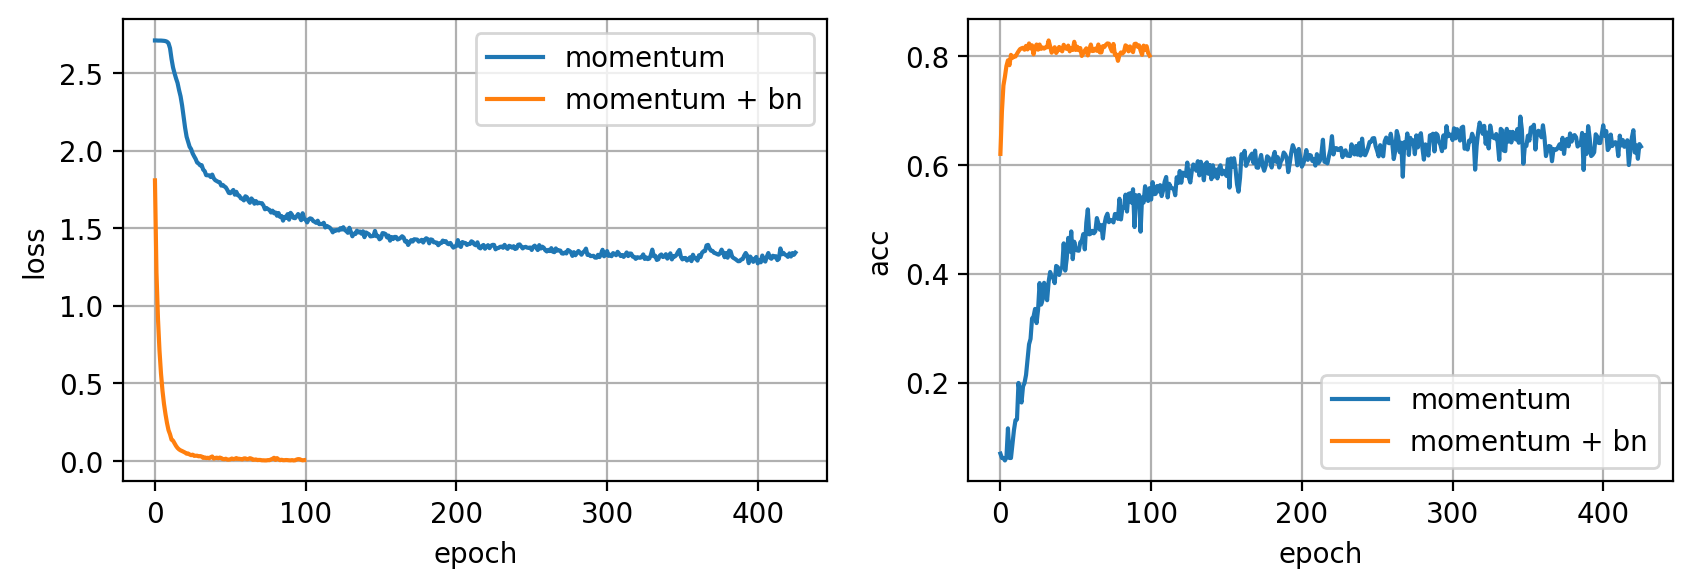

In [32]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_bn['loss'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_bn['val_acc'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()